In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

df = pd.read_csv('kyphosis.csv')
df.head()

,Kyphosis,Age,Number,Start
0,absent,71,3,5
1,absent,158,3,14
2,present,128,4,5
3,absent,2,5,1
4,absent,1,4,15


In [2]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81 entries, 0 to 80
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Kyphosis  81 non-null     object
 1   Age       81 non-null     int64 
 2   Number    81 non-null     int64 
 3   Start     81 non-null     int64 
dtypes: int64(3), object(1)
memory usage: 2.7+ KB


,Age,Number,Start
count,81.000000,81.000000,81.000000
mean,83.654321,4.049383,11.493827
std,58.104251,1.619423,4.883962
min,1.000000,2.000000,1.000000
25%,26.000000,3.000000,9.000000
50%,87.000000,4.000000,13.000000
75%,130.000000,5.000000,16.000000
max,206.000000,10.000000,18.000000


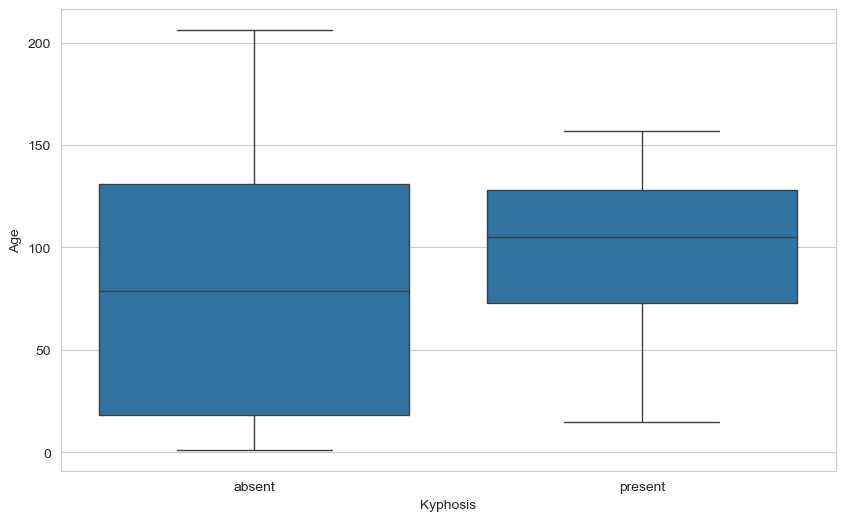

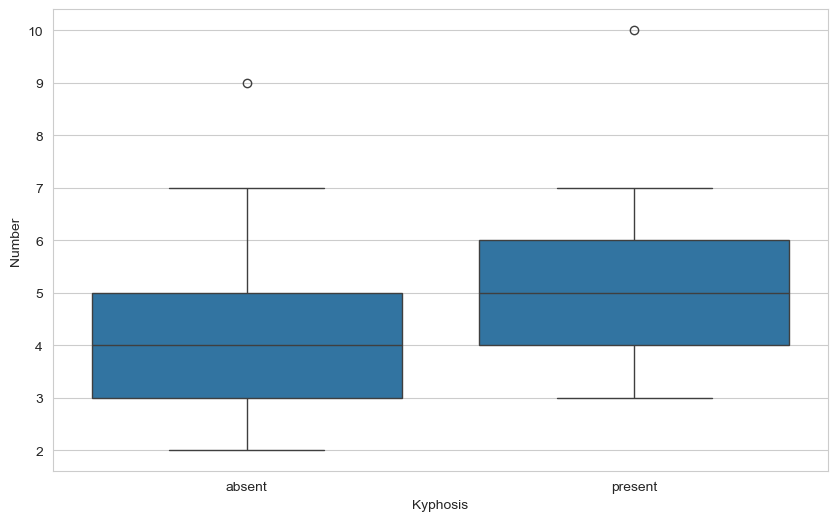

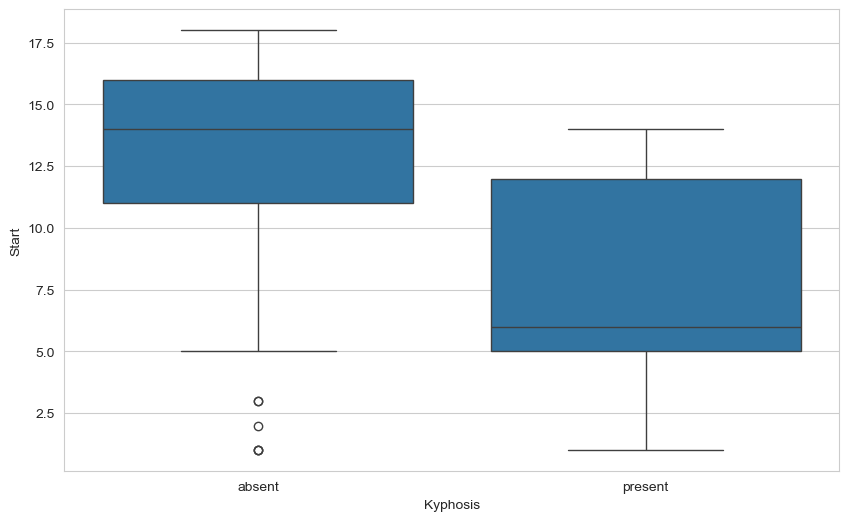

In [3]:
sns.set_style('whitegrid')
plt.figure(figsize=(10,6))
sns.boxplot(x='Kyphosis', y='Age', data=df)
plt.show()

plt.figure(figsize=(10,6))
sns.boxplot(x='Kyphosis', y='Number', data=df)
plt.show()

plt.figure(figsize=(10,6))
sns.boxplot(x='Kyphosis', y='Start', data=df)
plt.show()

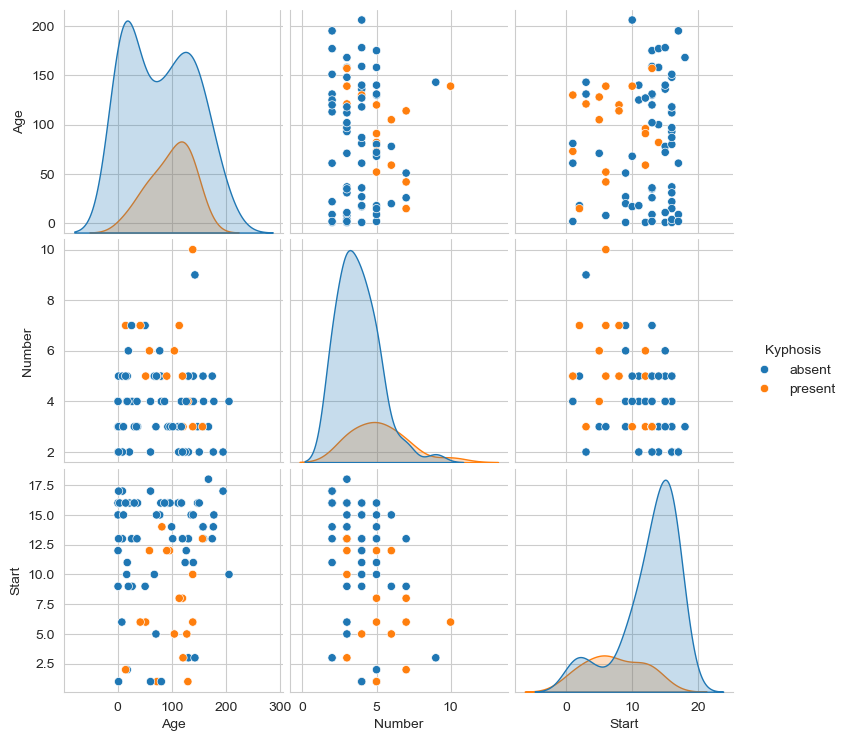

In [4]:
sns.pairplot(df, hue='Kyphosis')
plt.show()

In [5]:
X = df.drop('Kyphosis', axis=1)
y = df['Kyphosis']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

              precision    recall  f1-score   support

      absent       0.77      0.89      0.83        19
     present       0.33      0.17      0.22         6

    accuracy                           0.72        25
   macro avg       0.55      0.53      0.53        25
weighted avg       0.67      0.72      0.68        25



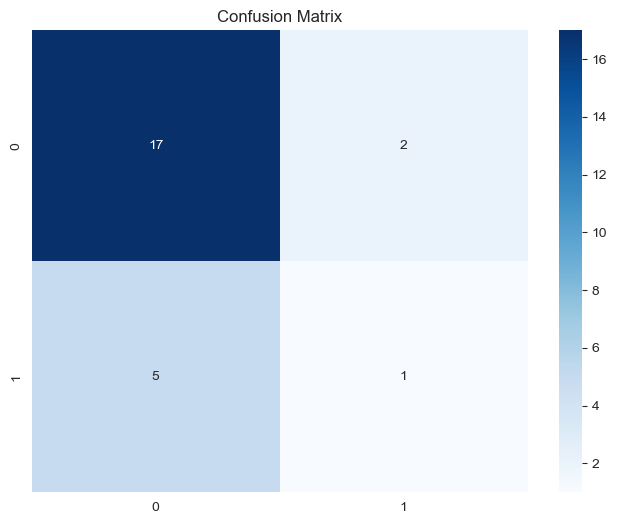

In [6]:
dtree = DecisionTreeClassifier()
dtree.fit(X_train, y_train)

predictions = dtree.predict(X_test)

print(classification_report(y_test, predictions))

plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, predictions), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

In [7]:
param_grid = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(DecisionTreeClassifier(), param_grid, cv=5)
grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best score: {grid_search.best_score_:.4f}")

Best parameters: {'max_depth': 3, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best score: 0.8758


              precision    recall  f1-score   support

      absent       0.78      0.95      0.86        19
     present       0.50      0.17      0.25         6

    accuracy                           0.76        25
   macro avg       0.64      0.56      0.55        25
weighted avg       0.71      0.76      0.71        25



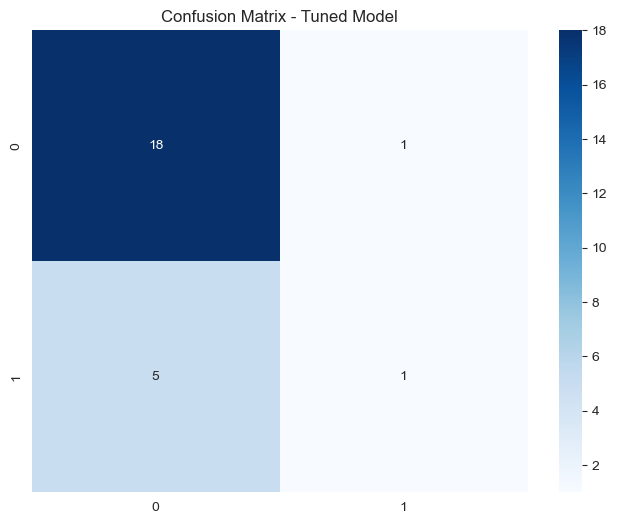

In [8]:
best_model = grid_search.best_estimator_
final_predictions = best_model.predict(X_test)

print(classification_report(y_test, final_predictions))

plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, final_predictions), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Tuned Model')
plt.show()

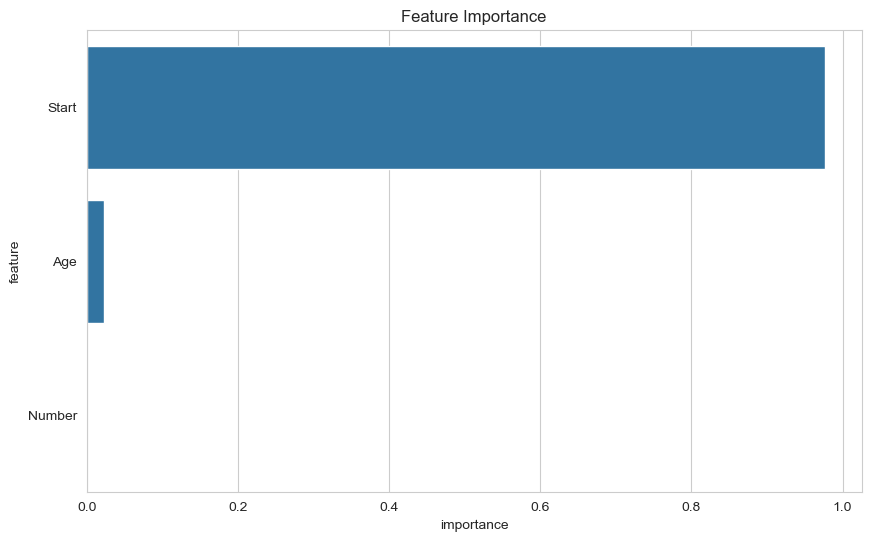

In [9]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': best_model.feature_importances_
})

plt.figure(figsize=(10,6))
sns.barplot(x='importance', y='feature', data=feature_importance.sort_values('importance', ascending=False))
plt.title('Feature Importance')
plt.show()

## Random Forest Classification

Random Forest Initial Model Performance:

Classification Report:
              precision    recall  f1-score   support

      absent       0.79      1.00      0.88        19
     present       1.00      0.17      0.29         6

    accuracy                           0.80        25
   macro avg       0.90      0.58      0.58        25
weighted avg       0.84      0.80      0.74        25



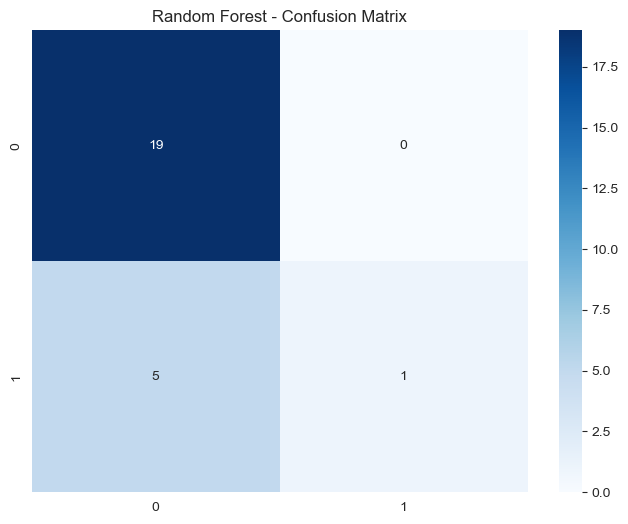

In [10]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

print("Random Forest Initial Model Performance:")
print("\nClassification Report:")
print(classification_report(y_test, rf_predictions))

plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, rf_predictions), annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest - Confusion Matrix')
plt.show()

Random Forest Grid Search Results:
Best parameters: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Best cross-validation score: 0.8591

Tuned Random Forest Performance:

Classification Report:
              precision    recall  f1-score   support

      absent       0.79      1.00      0.88        19
     present       1.00      0.17      0.29         6

    accuracy                           0.80        25
   macro avg       0.90      0.58      0.58        25
weighted avg       0.84      0.80      0.74        25



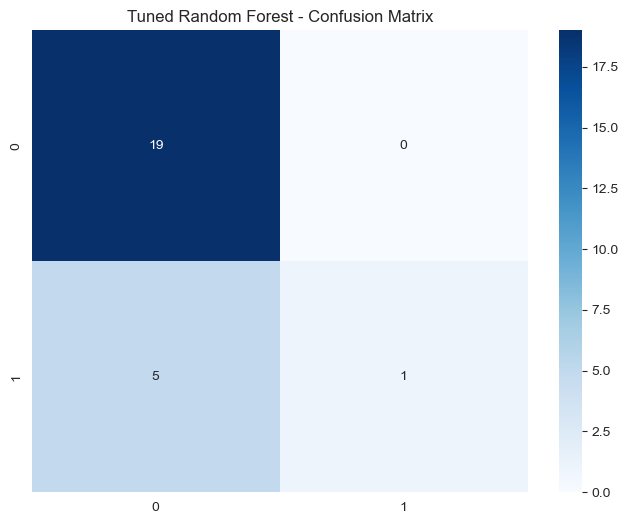

In [11]:
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_grid_search = GridSearchCV(RandomForestClassifier(random_state=42), rf_param_grid, cv=5)
rf_grid_search.fit(X_train, y_train)

print("Random Forest Grid Search Results:")
print(f"Best parameters: {rf_grid_search.best_params_}")
print(f"Best cross-validation score: {rf_grid_search.best_score_:.4f}")

rf_best_model = rf_grid_search.best_estimator_
rf_final_predictions = rf_best_model.predict(X_test)

print("\nTuned Random Forest Performance:")
print("\nClassification Report:")
print(classification_report(y_test, rf_final_predictions))

plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, rf_final_predictions), annot=True, fmt='d', cmap='Blues')
plt.title('Tuned Random Forest - Confusion Matrix')
plt.show()

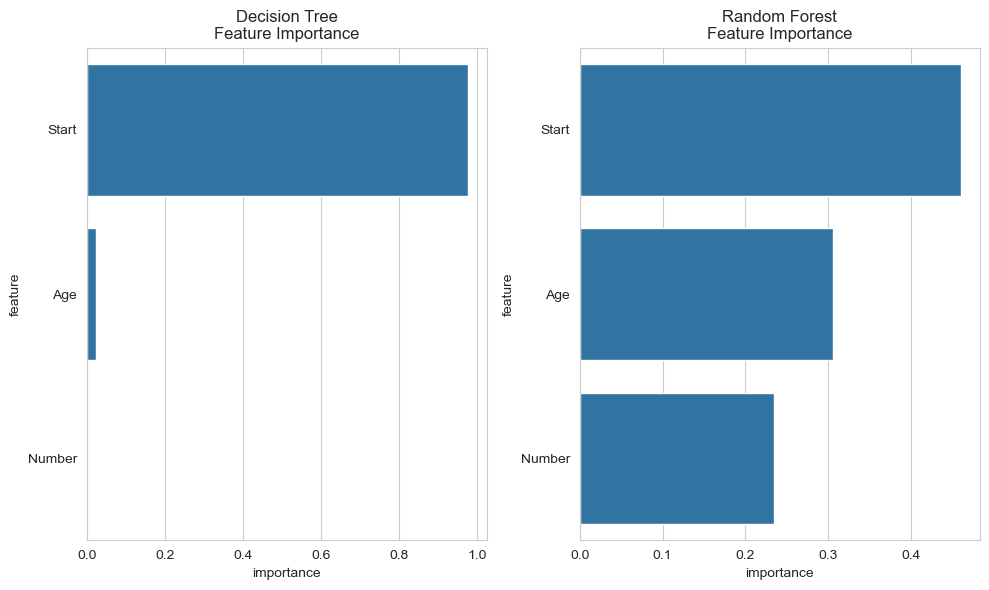


Model Comparison:
      Metric  Decision Tree  Random Forest
0   Accuracy         0.7600         0.8000
1  Precision         0.7148         0.8417
2     Recall         0.7600         0.8000
3   F1-Score         0.7114         0.7402


In [12]:
rf_feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_best_model.feature_importances_
})

plt.figure(figsize=(10,6))
plt.subplot(1, 2, 1)
sns.barplot(x='importance', y='feature', data=feature_importance.sort_values('importance', ascending=False))
plt.title('Decision Tree\nFeature Importance')

plt.subplot(1, 2, 2)
sns.barplot(x='importance', y='feature', data=rf_feature_importance.sort_values('importance', ascending=False))
plt.title('Random Forest\nFeature Importance')
plt.tight_layout()
plt.show()

comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Decision Tree': [
        classification_report(y_test, final_predictions, output_dict=True)['accuracy'],
        classification_report(y_test, final_predictions, output_dict=True)['weighted avg']['precision'],
        classification_report(y_test, final_predictions, output_dict=True)['weighted avg']['recall'],
        classification_report(y_test, final_predictions, output_dict=True)['weighted avg']['f1-score']
    ],
    'Random Forest': [
        classification_report(y_test, rf_final_predictions, output_dict=True)['accuracy'],
        classification_report(y_test, rf_final_predictions, output_dict=True)['weighted avg']['precision'],
        classification_report(y_test, rf_final_predictions, output_dict=True)['weighted avg']['recall'],
        classification_report(y_test, rf_final_predictions, output_dict=True)['weighted avg']['f1-score']
    ]
})

print("\nModel Comparison:")
print(comparison_df.round(4))